# DNN Forward / Backward Propagation 직접 구현

NumPy Dense DNN, Mini-batch SGD, gradient checking 및 실험 결과.
필요한 구현은 src의 Python 모듈에서 import하여 사용한다.


## 1. 모듈 준비 및 import
아래 셀부터 순서대로 모두 실행한다. Colab에서는 모듈을 자동으로 가져오므로 추가 파일 업로드가 필요 없다.

In [1]:
from pathlib import Path
from urllib.request import urlopen
import sys
import numpy as np
import matplotlib.pyplot as plt

# 로컬 실행은 src 폴더를 사용하고, 새 Colab 실행은 필요한 모듈을 받아온다.
SOURCE_DIR = Path("src")
SOURCE_DIR.mkdir(exist_ok=True)
MODULE_REF = "70f05a34e1e1907847059ec565aa4eb3f1a0ba31"
BASE_URL = f"https://raw.githubusercontent.com/piaa1004/python/{MODULE_REF}"
for filename in ["opt_utils.py", "optimization.py", "testCases.py", "test_utils.py", "public_tests.py"]:
    destination = SOURCE_DIR / filename
    if not destination.exists():
        with urlopen(f"{BASE_URL}/src/{filename}", timeout=20) as response:
            destination.write_bytes(response.read())
if not Path("README.md").exists():
    with urlopen(f"{BASE_URL}/README.md", timeout=20) as response:
        Path("README.md").write_bytes(response.read())
sys.path.insert(0, str(SOURCE_DIR.resolve()))

from opt_utils import load_data, build_model, DenseLayer, SoftmaxCrossEntropy
from optimization import train, gradient_check
from public_tests import run_all_tests
print("모듈 import 완료")


모듈 import 완료


## 2. NumPy 데이터 생성·분할·표준화

Train: (800, 2) (800,)
Validation: (200, 2) (200,)
Train mean: [-3.60822483e-18 -5.55111512e-18]
Train std: [1. 1.]


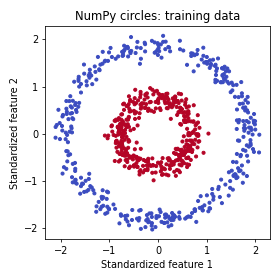

In [2]:
X_train, y_train, X_val, y_val = load_data(n_samples=1000, seed=42)
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Train mean:", X_train.mean(axis=0))
print("Train std:", X_train.std(axis=0))
fig_data, ax = plt.subplots(figsize=(4, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=10)
ax.set_xlabel("Standardized feature 1")
ax.set_ylabel("Standardized feature 2")
ax.set_title("NumPy circles: training data")
fig_data.tight_layout()
plt.show()


## 3. Forward / Backward와 shape 확인
배치 8개에 대해 Dense 3개와 활성함수의 계산 그래프를 확인한다.

In [3]:
model = build_model(seed=7)
a = X_train[:8]
print("Input:", a.shape)
for layer in model.layers:
    a = layer.forward(a)
    print(type(layer).__name__, "output:", a.shape)
criterion = SoftmaxCrossEntropy()
loss_value = criterion.forward(a, y_train[:8])
dX = model.backward(criterion.backward())
print("Loss:", loss_value, "dX:", dX.shape)
for i, layer in enumerate(model.layers):
    if isinstance(layer, DenseLayer):
        print(f"Layer {i}: W={layer.W.shape}, dW={layer.dW.shape}, b={layer.b.shape}, db={layer.db.shape}")


Input: (8, 2)
DenseLayer output: (8, 16)
ReLU output: (8, 16)
DenseLayer output: (8, 8)
Tanh output: (8, 8)
DenseLayer output: (8, 2)
Loss: 0.8548528353149144 dX: (8, 2)
Layer 0: W=(2, 16), dW=(2, 16), b=(1, 16), db=(1, 16)
Layer 2: W=(16, 8), dW=(16, 8), b=(1, 8), db=(1, 8)
Layer 4: W=(8, 2), dW=(8, 2), b=(1, 2), db=(1, 2)


## 4. 모듈 기능 검증
public_tests가 testCases와 test_utils를 import하여 입력·값·shape·학습을 검사한다.

In [4]:
run_all_tests()


test_01_dense_forward_backward_and_initialization (public_tests.DNNTests.test_01_dense_forward_backward_and_initialization) ... ok
test_02_activation_derivatives (public_tests.DNNTests.test_02_activation_derivatives) ... ok
test_03_softmax_cross_entropy (public_tests.DNNTests.test_03_softmax_cross_entropy) ... ok
test_04_data_split_and_standardization (public_tests.DNNTests.test_04_data_split_and_standardization) ... ok
test_05_minibatch_coverage_and_alignment (public_tests.DNNTests.test_05_minibatch_coverage_and_alignment) ... ok
test_06_model_and_sgd_update (public_tests.DNNTests.test_06_model_and_sgd_update) ... ok
test_07_gradient_check_and_parameter_restoration (public_tests.DNNTests.test_07_gradient_check_and_parameter_restoration) ... ok
test_08_training_loss_and_accuracy (public_tests.DNNTests.test_08_training_loss_and_accuracy) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.322s

OK


## 5. 중앙차분 Gradient checking

In [5]:
errors = gradient_check(build_model(seed=7), X_train[:5], y_train[:5], epsilon=1e-5)
for name, error in errors.items():
    print(f"Gradient checking {name}: {error:.3e}")
assert max(errors.values()) < 1e-6
print("Gradient checking 통과")


Gradient checking layer_0.W: 5.710e-11
Gradient checking layer_0.b: 3.929e-11
Gradient checking layer_2.W: 6.888e-11
Gradient checking layer_2.b: 5.641e-11
Gradient checking layer_4.W: 2.101e-11
Gradient checking layer_4.b: 2.287e-11
Gradient checking 통과


## 6. Mini-batch SGD 학습 및 학습률 비교

In [6]:
import csv
import json

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
histories = {}
summary = {"gradient_check": errors, "experiments": []}
for lr in (0.01, 0.05):
    model, history = train(epochs=200, batch_size=32, learning_rate=lr, seed=42)
    histories[lr] = history
    with (results_dir / f"logs_lr_{lr}.csv").open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(history[0]))
        writer.writeheader()
        writer.writerows(history)
    summary["experiments"].append({"learning_rate": lr, "epochs": 200,
        "batch_size": 32, "seed": 42, "final": history[-1]})
    for h in history:
        if h["epoch"] == 1 or h["epoch"] % 50 == 0:
            print(f"lr={lr}, epoch={h['epoch']:3d}, train loss={h['train_loss']:.6f}, "
                  f"train acc={h['train_accuracy']:.1%}, val loss={h['val_loss']:.6f}, "
                  f"val acc={h['val_accuracy']:.1%}")
(results_dir / "summary.json").write_text(json.dumps(summary, indent=2))


lr=0.01, epoch=  1, train loss=0.695601, train acc=51.0%, val loss=0.705006, val acc=49.0%
lr=0.01, epoch= 50, train loss=0.086838, train acc=100.0%, val loss=0.093583, val acc=100.0%
lr=0.01, epoch=100, train loss=0.026837, train acc=100.0%, val loss=0.031065, val acc=100.0%
lr=0.01, epoch=150, train loss=0.014625, train acc=100.0%, val loss=0.017735, val acc=100.0%
lr=0.01, epoch=200, train loss=0.009770, train acc=100.0%, val loss=0.012252, val acc=100.0%
lr=0.05, epoch=  1, train loss=0.591758, train acc=70.4%, val loss=0.603256, val acc=68.0%
lr=0.05, epoch= 50, train loss=0.007191, train acc=100.0%, val loss=0.009320, val acc=100.0%
lr=0.05, epoch=100, train loss=0.002941, train acc=100.0%, val loss=0.004128, val acc=100.0%
lr=0.05, epoch=150, train loss=0.001776, train acc=100.0%, val loss=0.002620, val acc=100.0%
lr=0.05, epoch=200, train loss=0.001253, train acc=100.0%, val loss=0.001908, val acc=100.0%


## 7. 학습/검증 곡선

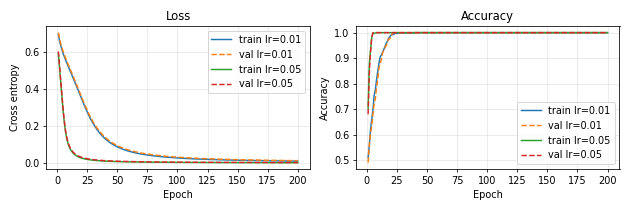

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for lr, history in histories.items():
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train_loss"] for h in history], label=f"train lr={lr}")
    axes[0].plot(epochs, [h["val_loss"] for h in history], "--", label=f"val lr={lr}")
    axes[1].plot(epochs, [h["train_accuracy"] for h in history], label=f"train lr={lr}")
    axes[1].plot(epochs, [h["val_accuracy"] for h in history], "--", label=f"val lr={lr}")
for ax, title, ylabel in zip(axes, ["Loss", "Accuracy"], ["Cross entropy", "Accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(results_dir / "learning_curves.png", dpi=90)
plt.show()


# DNN Forward / Backward Propagation 구현 보고서

## 모델과 데이터
NumPy로 2차원 circles 데이터 1,000개를 직접 생성했다. 반지름 1.0과 0.4인 원에 표준편차 0.06의 가우시안 잡음을 더했다.
무작위로 학습 800개 / 검증 200개를 분할했으며 학습 데이터의 평균과 표준편차만 사용해 두 데이터를 표준화했다.
별도 최종 테스트 세트는 없으므로 기록한 성능은 검증 성능이다.

모델: 입력(2) → Dense(16) → ReLU → Dense(8) → Tanh → Dense(2) → Softmax Cross Entropy.
Dense는 총 3개, 은닉층은 2개, 학습 파라미터는 총 202개다.
모든 레이어는 (batch, features)를 유지한다. 가중치는 (입력차원, 출력차원), 편향은 (1, 출력차원)이다.
입력은 (N,2), 은닉층 출력은 (N,16), (N,8), 최종 logits은 (N,2)이다.

## 초기화·활성함수·손실함수
ReLU 앞 Dense는 He 초기화, Tanh와 출력 Dense는 Xavier 초기화를 적용했다. 편향은 0으로 초기화했다.
ReLU는 간단한 비선형성을 제공하며 양수 영역에서 기울기를 유지한다. Tanh는 매끄러운 비선형성을 제공한다.
두 클래스의 logits에 Softmax Cross Entropy를 적용하여 확률 정규화와 분류 손실을 함께 계산했다.
행별 최대 logits를 빼고 log-sum-exp를 사용하여 큰 값에서의 overflow를 방지했다.

## Forward와 직접 미분
Dense는 Z = XW+b를 계산하고 입력 X를 cache에 저장한다.
ReLU는 X>0 마스크를, Tanh는 활성화 출력을, 손실은 확률과 정답 label을 저장한다.

- Dense: dW = XᵀdZ, db = sum(dZ, axis=0, keepdims=True), dX = dZWᵀ.
- ReLU: dX = dout × 1[X>0]. X=0에서 미분값은 0으로 정의한다.
- Tanh: dX = dout × (1−tanh(X)²).
- Softmax CE: dlogits = (softmax(logits)−one_hot(y))/N.

배치 평균은 손실의 backward에서 한 번만 적용한다. Dense에서 다시 배치 크기로 나누지 않는다.
모델의 backward는 레이어를 역순으로 방문하며, SGD는 W←W−lr×dW, b←b−lr×db로 갱신한다.
자동미분 또는 딥러닝 프레임워크를 사용하지 않았다.

## Gradient checking
모델 seed=7, 데이터 seed=42의 학습 샘플 5개에 대해 모든 Dense의 W와 b를 검사했다.
중앙차분 g_num = (L(θ+ε)−L(θ−ε))/(2ε), ε=1e-5를 사용했다.
상대오차 = ||g_analytic−g_num||₂/(||g_analytic||₂+||g_num||₂+1e-12).
통과 기준은 1e-6이며 수치미분 후 원래 파라미터와 cache를 복원한다.

| 파라미터 | 상대오차 |
|---|---|
| layer_0.W | 5.710e-11 |
| layer_0.b | 3.929e-11 |
| layer_2.W | 6.888e-11 |
| layer_2.b | 5.641e-11 |
| layer_4.W | 2.101e-11 |
| layer_4.b | 2.287e-11 |

ReLU는 0에서 미분이 불연속이므로 수치미분에 사용한 입력에서 꺾이는 지점을 피해야 한다.
위 검사에서는 모든 오차가 기준보다 작아 통과했다.

## 실험 결과
200 epoch, batch size=32, 데이터 seed=42, 모델 seed=7, SGD를 사용했다.
같은 데이터·초기화·배치 순서에서 학습률만 0.01과 0.05로 바꾸었다.
매 epoch가 끝난 뒤 같은 파라미터 상태로 전체 학습/검증 loss와 accuracy를 계산했다.

| 학습률 | Train loss | Train accuracy | Val loss | Val accuracy |
|---|---|---|---|---|
| 0.01 | 0.009770 | 100.0% | 0.012252 | 100.0% |
| 0.05 | 0.001253 | 100.0% | 0.001908 | 100.0% |

두 학습률 모두 검증 정확도 100%에 도달했으며 0.05가 더 낮은 최종 loss를 기록했다.
각 epoch 로그는 CSV로 저장하며 아래 코드에서 loss/accuracy 곡선을 출력한다.
한 종류의 쉬운 toy 데이터와 단일 seed로 실험했으므로 일반 데이터의 성능으로 해석하지 않는다.

## 파일 구성과 실행 방법

| 파일 | 역할 |
|---|---|
| DNN_Submission.ipynb | 모듈 import, shape 확인, 테스트, 학습, 결과 시각화 |
| src/opt_utils.py | 데이터·미니배치, Dense/활성함수/손실, 모델 컨테이너 |
| src/optimization.py | Mini-batch SGD 학습 및 gradient checking |
| src/testCases.py | 재현 가능한 테스트 입력과 기대값 |
| src/test_utils.py | 수치미분·상대오차·shape/값 검사 |
| src/public_tests.py | 위 모듈을 실제 import하여 기능 검증 |
| README.md | 구현 설명과 실험 결과 |
| results/ | epoch별 CSV, summary.json, 학습 곡선 |

Google Colab에서 DNN_Submission.ipynb를 열고 런타임 → 모두 실행을 선택한다.
노트북만 업로드해도 첫 셀이 GitHub의 고정된 버전에서 필요한 .py 파일과 README를 받아 src 폴더를 구성한다.
ZIP 전체를 내려받아 로컬에서 실행할 때는 src 폴더와 노트북을 같은 프로젝트에 두면 다운로드가 필요 없다.
외부 데이터나 GPU는 필요 없다. 기존 교수님 파일을 별도로 덮어쓸 필요도 없다.
로컬 Python 패키지는 NumPy, Matplotlib이며 설치 명령은 `pip install -r requirements.txt`다.
기능 검증은 프로젝트 폴더에서 `python src/public_tests.py`로 실행한다.

첨부 Optimization.ipynb의 mini-batch/SGD 실습 흐름과 opt_utils.py/testCases.py/test_utils.py/public_tests.py의 모듈 역할을 참고했다.
기존 데이터 방향 (features,batch)은 사용자 조건 (batch,features)에 맞게 변경했다.
시험 조건에 따라 data.mat 대신 NumPy로 circles 데이터를 직접 생성한다.
